# Where a concept lands early vs how broadly it spreads — the G (gateway-landing) screen

This notebook is a runnable demo of the experiment artifact **"Where a concept lands early vs how broadly it spreads"**,
part of a study of *scientific emergence as a network process* on OpenAlex.

**Question.** Suppose a new concept is picked up early (years t0..t0+2) by venues from *gateway* fields. A gateway field
is eigenvector-central in a 1998–2002 field-relatedness backbone. Does this early landing predict how broadly the concept
later spreads across disciplines? The test asks for signal *beyond* a simple volume/growth/breadth baseline, **B5**.

**What the code does** (the same as the original `method.py`, split into cells):
1. Builds concept features for the 46 development ("dev") concepts of the frozen P78 panel. These are the candidate **G**, its
   variants (degree, betweenness and φ_min gateways, Rao–Stirling, domain shares) and ~20 simple reference indicators
   (counts, share, growth, acceleration, Kleinberg burst, entropy, reach, off-home share).
2. Computes the authoritative **outcomes**: O1 sustained uptake, O2r rarefied venue-field breadth (m=30/50) and O3 transience.
3. Runs the pre-registered **S0 screen**. It fits a leave-one-home-group-out (CS / Eng / BGM / Med) ridge or logistic model of
   B5 vs B5+G and reports a paired concept bootstrap for Δρ / ΔAUC, split-half reliability, size correlations and survival clauses.
4. Runs sensitivities, exploratory secondary screens and the **field-level retention** test (does the adopting field's gateway
   centrality predict that it keeps the concept?).
5. Builds the **single-indicator table** (pooled, per-group and DerSimonian–Laird random-effects with I²).
6. Runs the **next-field entry** test: relatedness density (Hidalgo et al. 2007) vs a field-size baseline, with a conditional
   logit and a permutation null.

**Data.** The original script reads a frozen OpenAlex API cache (`cache/raw`, ~40 MB) and the public OpenAlex S3 sources
snapshot (~370 MB). To keep the demo self-contained, `mini_demo_data.json` holds the *already assembled* output of the
original `assemble()` (all 78 panel concepts: yearly counts and venue-field counts per window) and of `backbone.build()`
(the 26-field PMI backbone). Everything downstream of those two calls is the original code.

**Runtime.** Bootstrap and permutation counts are in the config cell. They are set so the whole notebook runs in a few
minutes; the original values are noted next to each one.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, scikit-learn, statsmodels, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'scikit-learn==1.6.1', 'statsmodels==0.14.6',
         'matplotlib==3.10.0')

## Imports

This cell holds the original `method.py` import block plus the imports of the helper modules it used
(`features.py`, `screen.py`, `next_field.py`, `report.py`). Those modules are copied into the cells below, so the
`import oa_client` / `from assemble import ...` lines are no longer needed.

In [2]:
from __future__ import annotations

import json
import math
import sys
import time
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy.special import gammaln
from scipy.stats import norm, rankdata, spearmanr
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.discrete.conditional_models import ConditionalLogit

import matplotlib.pyplot as plt

# In the original all outputs were written next to method.py; here they go to ./demo_outputs
ROOT = Path("demo_outputs").resolve()
ROOT.mkdir(exist_ok=True)
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG");
# original: resource.setrlimit(resource.RLIMIT_AS, (12 GB, 12 GB)) — dropped: it can break Colab's preloaded libraries

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_AawnV1HvzpNx/round-1/experiment-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("concepts in panel:", len(data["assembled"]["concepts"]), "| backbone fields:", len(data["backbone"]["fields"]))

Assembled P78 panel (output of assemble(): per-concept yearly counts, venue-field counts per window A/B/C/D, home, group) plus the 26-field 1998-2002 positive-PMI backbone (output of backbone.build()). Pre-computed offline from the frozen OpenAlex cache and S3 sources snapshot so the demo needs no API key and no 370 MB snapshot.
concepts in panel: 78 | backbone fields: 26


## Configuration

These are all the tunable resampling parameters. The demo values keep the total runtime within a few minutes on a
2-CPU machine. The **original values** are given in the comments. Setting every parameter back to its original value
reproduces the published numbers bit for bit (all seeds are fixed).

In [5]:
N_BOOT = 2000            # paired concept bootstrap resamples per screen / field-level test   (original: 2000)
REFIT_BOOT = 200          # stratified refit bootstrap for the primary O2r screen                (original: 200)
MC_SIMS = 100_000          # Monte Carlo draws validating the exact rarefaction formula             (original: 100_000)
N_REL_SPLITS = 50        # random split-halves for split-half reliability                          (original: 50)
NF_N_BOOT = 2000         # concept bootstrap resamples in the next-field entry test              (original: 2000)
NF_N_PERM = 1000         # permutation-null draws (shuffled backbone) in next-field entry test     (original: 1000)
CLOGIT_BOOT = 200        # cluster bootstrap refits of the conditional logit                        (original: 200)
TRUNC_THR = 0.15      # outcome window counts as truncated if > 15% of papers fall outside the top-200 sources (fixed)

## Helper module 1 — `features.py`: G family, reference indicators, outcomes

These are the original functions, unchanged:
* `rarefied_richness`: exact hypergeometric rarefaction E[S_m]. It gives the **O2r** outcome: how many distinct venue
  fields a random sample of m=30 (or 50) outcome-window papers would span, so breadth is compared at equal size.
* `kleinberg_batched`: a 2-state Kleinberg burst detector (own Viterbi) used as a reference indicator.
* `Backbone`: wraps the 26-field positive-PMI backbone and the gateway centralities.
* `g_family`: the candidate **G**, defined as the off-home, paper-weighted mean gateway centrality of the fields adopting
  the concept. It also gives the variants (degree, betweenness and φ_min gateways), REL_home, Rao–Stirling diversity and domain shares.
* `label_indicators` / `count_indicators`: simple reference indicators (entropy, reach, off-home share; log count,
  share, growth, acceleration, burst).
* `outcomes`: **O1** sustained uptake (share in t0+6..t0+8 ≥ share at t0+5), **O3** transience (peak between t0+3 and t0+8
  and ≥2× the late level), and O2r / O2_raw from the outcome window D (t0+6..t0+8).

In [6]:
HOME_DEV = {"CS": "Computer Science", "Eng": "Engineering",
            "BGM": "Biochemistry, Genetics and Molecular Biology", "Med": "Medicine"}


# ------------------------------------------------------------------ primitives
def rarefied_richness(counts: list[int] | np.ndarray, m: int) -> float:
    """Exact hypergeometric rarefaction E[S_m] = sum_j 1 - C(N-n_j, m)/C(N, m)."""
    n = np.asarray([c for c in counts if c > 0], dtype=float)
    N = n.sum()
    if N < m:
        return math.nan
    lc = lambda a, b: gammaln(a + 1) - gammaln(b + 1) - gammaln(a - b + 1)
    out = 0.0
    for nj in n:
        if N - nj < m:
            out += 1.0
        else:
            out += 1.0 - math.exp(lc(N - nj, m) - lc(N, m))
    return out


def shannon(c: dict) -> float:
    v = np.array([x for x in c.values() if x > 0], dtype=float)
    if v.sum() == 0:
        return math.nan
    p = v / v.sum()
    return float(-(p * np.log(p)).sum())


def kleinberg_batched(r: list[int], d: list[int], s: float = 2.0, gamma: float = 1.0) -> tuple[list[int], float]:
    """Kleinberg (2002) 2-state batched burst detection (own Viterbi). Returns states and burst weight."""
    r = np.asarray(r, float)
    d = np.asarray(d, float)
    n = len(r)
    p0 = r.sum() / d.sum()
    p1 = min(s * p0, 0.9999)

    def cost(p):
        return -(r * math.log(p) + (d - r) * math.log(1 - p))
    c = np.vstack([cost(p0), cost(p1)])
    trans = gamma * math.log(n)
    V = np.zeros((2, n))
    back = np.zeros((2, n), int)
    V[0, 0], V[1, 0] = c[0, 0], c[1, 0] + trans
    for t in range(1, n):
        for q in (0, 1):
            cand = [V[0, t - 1] + (trans if q == 1 else 0), V[1, t - 1]]
            back[q, t] = int(np.argmin(cand))
            V[q, t] = min(cand) + c[q, t]
    st = [int(np.argmin(V[:, -1]))]
    for t in range(n - 1, 0, -1):
        st.append(back[st[-1], t])
    st = st[::-1]
    weight = float(sum(c[0, t] - c[1, t] for t in range(n) if st[t] == 1))
    return st, weight


def cohort_split_half(mats: list[list[str]], fn, n_splits: int = 50, seed: int = 0) -> dict:
    """Split-half reliability across concepts: split each concept's paper-label list into random halves,
    compute fn(labels) per half, Spearman across concepts, Spearman-Brown corrected."""
    rng = np.random.default_rng(seed)
    rs = []
    for _ in range(n_splits):
        a, b = [], []
        for labels in mats:
            idx = rng.permutation(len(labels))
            h = len(labels) // 2
            a.append(fn([labels[i] for i in idx[:h]]))
            b.append(fn([labels[i] for i in idx[h:2 * h]]))
        a, b = np.array(a, float), np.array(b, float)
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() >= 5:
            r = spearmanr(a[ok], b[ok]).statistic
            if np.isfinite(r):
                rs.append(2 * r / (1 + r) if r > -1 else np.nan)
    rs = np.array(rs, float)
    if len(rs) == 0:
        return {"r_sb_median": math.nan, "p05": math.nan, "p95": math.nan, "n_splits": 0}
    return {"r_sb_median": float(np.nanmedian(rs)), "p05": float(np.nanpercentile(rs, 5)),
            "p95": float(np.nanpercentile(rs, 95)), "n_splits": int(len(rs))}


# ------------------------------------------------------------------ feature builders
class Backbone:
    def __init__(self, b: dict):
        self.fields = b["fields"]
        self.idx = {f: i for i, f in enumerate(self.fields)}
        self.phi = np.array(b["phi"])
        self.phi_min = np.array(b["phi_min"])
        self.gate = {k: np.array(b[k]) for k in ("gateway_eig", "gateway_deg", "gateway_btw", "gateway_eig_phimin")}
        self.domain = b["domain"]
        self.logsize = np.log(np.array(b["n_field"]))

    def g(self, f: str, kind: str = "gateway_eig") -> float:
        return float(self.gate[kind][self.idx[f]])


def g_family(fc: dict, home: list[str], bb: Backbone) -> dict:
    """G and secondaries from a field-count dict (labelled papers)."""
    tot = sum(fc.values())
    out = {}
    off = {f: n for f, n in fc.items() if f not in home and n > 0}
    offt = sum(off.values())
    for kind, nm in (("gateway_eig", "G"), ("gateway_deg", "G_deg"), ("gateway_btw", "G_btw"),
                     ("gateway_eig_phimin", "G_phimin")):
        out[nm] = sum(n * bb.g(f, kind) for f, n in off.items()) / offt if offt else math.nan
    out["G_all"] = sum(n * bb.g(f) for f, n in fc.items()) / tot if tot else math.nan
    hi = [bb.idx[h] for h in home if h in bb.idx]
    out["REL_home"] = (sum(n * np.mean([bb.phi[i, bb.idx[f]] for i in hi]) for f, n in off.items()) / offt
                       if offt and hi else math.nan)
    if tot:
        p = np.zeros(26)
        for f, n in fc.items():
            p[bb.idx[f]] = n / tot
        D = 1 - bb.phi_min
        np.fill_diagonal(D, 0)
        out["RS"] = float(p @ D @ p)
        for dom in ("Physical", "Life", "Health", "Social"):
            out[f"DOM_{dom}"] = float(sum(p[i] for i in range(26) if bb.domain[i] == dom))
    else:
        out["RS"] = math.nan
        for dom in ("Physical", "Life", "Health", "Social"):
            out[f"DOM_{dom}"] = math.nan
    top5 = set(np.argsort(bb.gate["gateway_eig"])[::-1][:5])
    out["GATEWAY_REACH"] = sum(1 for f, n in fc.items() if n >= 2 and bb.idx[f] in top5)
    return out


def g_from_labels(labels: list[str], home: list[str], bb: Backbone) -> float:
    return g_family(Counter(labels), home, bb)["G"]


def label_indicators(fc: dict, home: list[str], total: int) -> dict:
    lab = sum(fc.values())
    off = sum(n for f, n in fc.items() if f not in home)
    return {"entropy": shannon(fc) if lab else math.nan,
            "reach": sum(1 for n in fc.values() if n >= 2),
            "offhome_share": off / lab if lab else math.nan,
            "log_offhome_volume": math.log1p(off),
            "label_coverage": lab / total if total else math.nan}


def count_indicators(yc: dict, gtot: dict, t0: int, end: int) -> dict:
    ys = list(range(t0, end + 1))
    n = np.array([yc.get(y, 0) for y in ys], float)
    out = {"log_count": math.log1p(n.sum()), "share": n.sum() / sum(gtot[y] for y in ys) * 1e6,
           "growth": math.log((yc.get(end, 0) + 1) / (yc.get(t0 + 1, 0) + 1))}
    x = np.array(ys, float) - t0
    out["accel"] = float(np.polyfit(x, np.log1p(n), 2)[0]) if len(ys) >= 3 else math.nan
    yrs = list(range(t0 - 3, end + 1))
    _, w = kleinberg_batched([yc.get(y, 0) for y in yrs], [gtot[y] for y in yrs])
    out["burst"] = w
    return out


def outcomes(yc: dict, gtot: dict, t0: int, fcD: dict | None) -> dict:
    sh = lambda y: yc.get(y, 0) / gtot[y]
    o1 = int(np.mean([sh(y) for y in range(t0 + 6, t0 + 9)]) >= sh(t0 + 5))
    seq = [yc.get(y, 0) for y in range(t0, t0 + 9)]
    peak_y = t0 + int(np.argmax(seq))
    late = np.mean([yc.get(t0 + 7, 0), yc.get(t0 + 8, 0)])
    o3 = int(t0 + 3 <= peak_y <= t0 + 8 and max(seq) / max(late, 1e-9) >= 2)
    res = {"O1": o1, "O3": o3, "peak_year": peak_y}
    if fcD is not None:
        counts = list(fcD.values())
        N = int(sum(counts))
        res.update({"N_outcome": N, "O2r_m30": rarefied_richness(counts, 30),
                    "O2r_m50": rarefied_richness(counts, 50),
                    "O2_raw": int(sum(1 for c in counts if c >= 15))})
    else:
        res.update({"N_outcome": math.nan, "O2r_m30": math.nan, "O2r_m50": math.nan, "O2_raw": math.nan})
    return res

## Helper module 2 — `screen.py`: pre-registered S0 screen statistics

* `logo_predict`: **leave-one-home-group-out** out-of-fold predictions. Each concept is predicted by a model trained
  only on concepts from the *other three* home groups, which tests generalisation across domains. Missing values
  are median-imputed with the training-fold median.
* `paired_delta`: out-of-fold Spearman ρ (ridge) or AUC (logistic) for the baseline vs baseline+candidate, a paired
  concept bootstrap of the difference, per-group deltas, and an optional stratified *refit* bootstrap.
* `loco_delta`: the supplementary leave-one-concept-out version.
* `dersimonian_laird` / `single_indicator`: random-effects pooling of per-group Spearman (Fisher z) or AUC (logit),
  with I² heterogeneity and sign consistency.
* `field_level`: the same LOGO logistic scheme at the concept × field level, with a concept-clustered bootstrap.

In [7]:
warnings.filterwarnings("ignore", category=RuntimeWarning)
GROUPS = ["CS", "Eng", "BGM", "Med"]


def _prep(X: pd.DataFrame, train: np.ndarray) -> np.ndarray:
    """Median-impute each column with the TRAINING-fold median (G's missing indicator is a separate column)."""
    X = X.copy()
    for c in X.columns:
        med = X.loc[train, c].median()
        X[c] = X[c].fillna(med if np.isfinite(med) else 0.0)
    return X.values.astype(float)


def logo_predict(df: pd.DataFrame, cols: list[str], y: str, kind: str = "ridge") -> np.ndarray:
    """Leave-one-home-group-out out-of-fold predictions."""
    oof = np.full(len(df), np.nan)
    g = df["group"].values
    for lg in GROUPS:
        te = g == lg
        tr = ~te
        if te.sum() == 0 or tr.sum() < 5:
            continue
        Xall = _prep(df[cols], tr)
        yt = df.loc[tr, y].values
        if kind == "ridge":
            m = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
            m.fit(Xall[tr], yt)
            oof[te] = m.predict(Xall[te])
        else:
            if len(np.unique(yt)) < 2:
                oof[te] = yt.mean()
                continue
            m = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
            m.fit(Xall[tr], yt.astype(int))
            oof[te] = m.predict_proba(Xall[te])[:, 1]
    return oof


def _sp(a, b) -> float:
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 4 or np.std(a[ok]) == 0 or np.std(b[ok]) == 0:
        return math.nan
    return float(spearmanr(a[ok], b[ok]).statistic)


def _auc(y, p) -> float:
    ok = np.isfinite(p) & np.isfinite(y)
    if ok.sum() < 4 or len(np.unique(y[ok])) < 2:
        return math.nan
    return float(roc_auc_score(y[ok].astype(int), p[ok]))


def paired_delta(df: pd.DataFrame, base: list[str], cand: list[str], y: str, kind: str = "ridge",
                 n_boot: int = 2000, seed: int = 20260928, refit_boot: int = 0) -> dict:
    d = df[np.isfinite(df[y].values.astype(float))].reset_index(drop=True)
    ob = logo_predict(d, base, y, kind)
    oc = logo_predict(d, cand, y, kind)
    Y = d[y].values.astype(float)
    stat = _sp if kind == "ridge" else (lambda p, yy: _auc(yy, p))
    sb, sc = stat(ob, Y), stat(oc, Y)
    rng = np.random.default_rng(seed)
    n = len(d)
    boots = []
    for _ in range(n_boot):
        i = rng.integers(0, n, n)
        a, b = stat(ob[i], Y[i]), stat(oc[i], Y[i])
        if np.isfinite(a) and np.isfinite(b):
            boots.append(b - a)
    boots = np.array(boots)
    per = {}
    for g in GROUPS:
        m = d["group"].values == g
        pb, pc = stat(ob[m], Y[m]), stat(oc[m], Y[m])
        per[g] = {"n": int(m.sum()), "base": pb, "cand": pc,
                  "delta": (pc - pb) if np.isfinite(pb) and np.isfinite(pc) else math.nan}
    out = {"n": n, "metric": "spearman" if kind == "ridge" else "auc", "base": sb, "cand": sc, "delta": sc - sb,
           "ci90": [float(np.percentile(boots, 5)), float(np.percentile(boots, 95))] if len(boots) else [math.nan] * 2,
           "ci95": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))] if len(boots) else [math.nan] * 2,
           "p_boot_le0": float(np.mean(boots <= 0)) if len(boots) else math.nan,
           "per_group": per,
           "n_groups_positive": int(sum(1 for v in per.values() if np.isfinite(v["delta"]) and v["delta"] > 0)),
           "n_groups_evaluable": int(sum(1 for v in per.values() if np.isfinite(v["delta"]))),
           "oof_base": ob.tolist(), "oof_cand": oc.tolist(), "concepts": d["concept"].tolist()}
    if refit_boot:
        rr = []
        for _ in range(refit_boot):
            idx = np.concatenate([rng.choice(np.where(d["group"].values == g)[0], (d["group"].values == g).sum())
                                  for g in GROUPS if (d["group"].values == g).sum()])
            dd = d.iloc[idx].reset_index(drop=True)
            a = stat(logo_predict(dd, base, y, kind), dd[y].values.astype(float))
            b = stat(logo_predict(dd, cand, y, kind), dd[y].values.astype(float))
            if np.isfinite(a) and np.isfinite(b):
                rr.append(b - a)
        rr = np.array(rr)
        out["refit_boot"] = {"n": int(len(rr)), "ci90": [float(np.percentile(rr, 5)), float(np.percentile(rr, 95))]
                             if len(rr) else [math.nan] * 2, "mean": float(rr.mean()) if len(rr) else math.nan}
    return out


def loco_delta(df: pd.DataFrame, base: list[str], cand: list[str], y: str) -> dict:
    """Supplementary leave-one-concept-out ridge Delta-rho."""
    d = df[np.isfinite(df[y].values.astype(float))].reset_index(drop=True)
    res = {}
    for nm, cols in (("base", base), ("cand", cand)):
        oof = np.full(len(d), np.nan)
        for i in range(len(d)):
            tr = np.ones(len(d), bool)
            tr[i] = False
            X = _prep(d[cols], tr)
            m = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X[tr], d.loc[tr, y].values)
            oof[i] = m.predict(X[~tr])[0]
        res[nm] = _sp(oof, d[y].values.astype(float))
    return {"base": res["base"], "cand": res["cand"], "delta": res["cand"] - res["base"], "n": len(d)}


# ------------------------------------------------------------------ meta-analysis
def dersimonian_laird(est: list[float], var: list[float]) -> dict:
    e = np.array(est, float)
    v = np.array(var, float)
    ok = np.isfinite(e) & np.isfinite(v) & (v > 0)
    e, v = e[ok], v[ok]
    k = len(e)
    if k < 2:
        return {"k": k, "pooled": float(e[0]) if k else math.nan, "se": math.nan, "tau2": math.nan, "I2": math.nan}
    w = 1 / v
    fe = (w * e).sum() / w.sum()
    Q = (w * (e - fe) ** 2).sum()
    C = w.sum() - (w ** 2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / C) if C > 0 else 0.0
    ws = 1 / (v + tau2)
    re = (ws * e).sum() / ws.sum()
    se = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 else 0.0
    return {"k": k, "pooled": float(re), "se": float(se), "tau2": float(tau2), "I2": float(I2), "Q": float(Q)}


def hanley_mcneil_var(auc: float, n1: int, n0: int) -> float:
    q1, q2 = auc / (2 - auc), 2 * auc ** 2 / (1 + auc)
    return (auc * (1 - auc) + (n1 - 1) * (q1 - auc ** 2) + (n0 - 1) * (q2 - auc ** 2)) / (n1 * n0)


def single_indicator(df: pd.DataFrame, feat: str, y: str, binary: bool) -> dict:
    d = df[np.isfinite(df[y].values.astype(float)) & np.isfinite(df[feat].values.astype(float))]
    x, Y = d[feat].values.astype(float), d[y].values.astype(float)
    res = {"feature": feat, "outcome": y, "n": len(d)}
    if not binary:
        res["pooled"] = _sp(x, Y)
        ests, vars_, per = [], [], {}
        for g in GROUPS:
            m = d["group"].values == g
            r = _sp(x[m], Y[m])
            per[g] = r
            if np.isfinite(r) and m.sum() > 3:
                ests.append(math.atanh(max(min(r, 0.999), -0.999)))
                vars_.append(1.06 / (m.sum() - 3))
        dl = dersimonian_laird(ests, vars_)
        res.update({"per_group": per, "meta_pooled": math.tanh(dl["pooled"]) if np.isfinite(dl["pooled"]) else math.nan,
                    "meta_ci95": [math.tanh(dl["pooled"] - 1.96 * dl["se"]), math.tanh(dl["pooled"] + 1.96 * dl["se"])]
                    if np.isfinite(dl["se"]) else [math.nan] * 2, "I2": dl["I2"], "k": dl["k"],
                    "sign_consistency": int(sum(1 for v in per.values() if np.isfinite(v) and np.sign(v) ==
                                                np.sign(res["pooled"])))})
    else:
        res["pooled_raw"] = _auc(Y, x)
        per_raw, per_or, ests, vars_ = {}, {}, [], []
        for g in GROUPS:
            m = d["group"].values == g
            a = _auc(Y[m], x[m])
            per_raw[g] = a
            atr = _auc(Y[~m], x[~m])  # orientation chosen on training groups only
            sgn = 1 if (not np.isfinite(atr) or atr >= 0.5) else -1
            ao = a if sgn == 1 else (1 - a if np.isfinite(a) else a)
            per_or[g] = ao
            n1, n0 = int(Y[m].sum()), int((1 - Y[m]).sum())
            if np.isfinite(ao) and n1 and n0:
                aa = min(max(ao, 0.01), 0.99)
                ests.append(math.log(aa / (1 - aa)))
                vars_.append(hanley_mcneil_var(aa, n1, n0) / (aa * (1 - aa)) ** 2)
        dl = dersimonian_laird(ests, vars_)
        inv = lambda z: 1 / (1 + math.exp(-z))
        res.update({"per_group_raw": per_raw, "per_group_oriented": per_or,
                    "meta_pooled_oriented": inv(dl["pooled"]) if np.isfinite(dl["pooled"]) else math.nan,
                    "meta_ci95": [inv(dl["pooled"] - 1.96 * dl["se"]), inv(dl["pooled"] + 1.96 * dl["se"])]
                    if np.isfinite(dl["se"]) else [math.nan] * 2, "I2": dl["I2"], "k": dl["k"],
                    "sign_consistency": int(sum(1 for v in per_or.values() if np.isfinite(v) and v > 0.5))})
    return res


# ------------------------------------------------------------------ field level
def field_level(fr: pd.DataFrame, base: list[str], cand: list[str], n_boot: int = 2000, seed: int = 1) -> dict:
    d = fr.dropna(subset=["R"]).reset_index(drop=True)
    ob = logo_predict(d, base, "R", "logit")
    oc = logo_predict(d, cand, "R", "logit")
    Y = d["R"].values.astype(float)
    ab, ac = _auc(Y, ob), _auc(Y, oc)
    rng = np.random.default_rng(seed)
    cons = d["concept"].unique()
    rows = {c: np.where(d["concept"].values == c)[0] for c in cons}
    boots = []
    for _ in range(n_boot):
        pick = rng.choice(cons, len(cons))
        i = np.concatenate([rows[c] for c in pick])
        a, b = _auc(Y[i], ob[i]), _auc(Y[i], oc[i])
        if np.isfinite(a) and np.isfinite(b):
            boots.append(b - a)
    boots = np.array(boots)
    per = {}
    for g in GROUPS:
        m = d["group"].values == g
        per[g] = {"n_rows": int(m.sum()), "base": _auc(Y[m], ob[m]), "cand": _auc(Y[m], oc[m])}
    return {"n_rows": len(d), "n_concepts": len(cons), "prevalence": float(Y.mean()), "auc_base": ab, "auc_cand": ac,
            "delta_auc": ac - ab, "ci90": [float(np.percentile(boots, 5)), float(np.percentile(boots, 95))],
            "ci95": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))], "per_group": per}

## Helper module 3 — `next_field.py`: relatedness-density next-field entry test

This is the Hidalgo et al. (2007) *principle of relatedness* applied to concepts. The **density** of a not-yet-adopted
field k is the share of k's backbone relatedness that goes to fields the concept already occupies. There are two steps:
*short* (fields in window A → entered by t0+2) and *long* (fields in W3 → present in the outcome window). The test
compares within-concept-step AUCs of density against a **log field-size** baseline. It also fits a conditional logit
(concept-step strata) and a permutation null that shuffles the backbone's field labels.

The only change from the original is that the hard-coded 200 conditional-logit bootstrap refits are now the
`CLOGIT_BOOT` config variable.

In [8]:
def density(K: set[int], phi: np.ndarray) -> np.ndarray:
    den = phi.sum(axis=0)
    num = phi[list(K), :].sum(axis=0) if K else np.zeros(phi.shape[0])
    return np.where(den > 0, num / np.where(den > 0, den, 1), 0.0)


def build_rows(concepts: dict, bb) -> pd.DataFrame:
    """Steps: 'short' = A (t0..t0+1) -> t0+2 (cumulative >= 2 papers); 'long' = W3 -> outcome window (>= 3 papers)."""
    rows = []
    for nm, r in concepts.items():
        w = r.get("windows") or {}
        A, B, D = w.get("A"), w.get("B"), w.get("D")
        if not A or not B:
            continue
        cA = Counter(A["fields"])
        cW3 = cA + Counter(B["fields"])
        home_idx = [bb.idx[h] for h in r["home"] if h in bb.idx]
        steps = [("short", {bb.idx[f] for f, n in cA.items() if n >= 2},
                  lambda k: cW3.get(bb.fields[k], 0) >= 2)]
        if D:
            cD = Counter(D["fields"])
            steps.append(("long", {bb.idx[f] for f, n in cW3.items() if n >= 2},
                          lambda k, cD=cD: cD.get(bb.fields[k], 0) >= 3))
        for step, K, entered in steps:
            if not K:
                continue
            dens = density(K, bb.phi)
            for k in range(26):
                if k in K:
                    continue
                rows.append({"concept": nm, "group": r["group"], "step": step, "cs": f"{nm}|{step}",
                             "field": bb.fields[k], "k": k, "entered": int(entered(k)), "density": dens[k],
                             "log_size": bb.logsize[k],
                             "phi_home": float(np.mean([bb.phi[h, k] for h in home_idx])) if home_idx else 0.0})
    return pd.DataFrame(rows)


def per_cs_auc(df: pd.DataFrame, col: str) -> pd.Series:
    out = {}
    for cs, g in df.groupby("cs"):
        if g["entered"].nunique() == 2:
            out[cs] = roc_auc_score(g["entered"], g[col])
    return pd.Series(out)


def analyse(df: pd.DataFrame, bb, n_boot: int = 2000, n_perm: int = 1000, seed: int = 7) -> dict:
    rng = np.random.default_rng(seed)
    res = {"n_rows": len(df), "n_concept_steps": int(df["cs"].nunique()), "entry_rate": float(df["entered"].mean())}
    df = df.copy()
    df["dens_plus_size"] = np.nan
    for step in ("short", "long", "all"):
        d = df if step == "all" else df[df["step"] == step]
        if d.empty:
            continue
        a_den, a_size = per_cs_auc(d, "density"), per_cs_auc(d, "log_size")
        a_home = per_cs_auc(d, "phi_home")
        concepts = d["concept"].unique()

        def boot(series):
            idx = {c: [i for i in series.index if i.startswith(c + "|")] for c in concepts}
            bs = []
            for _ in range(n_boot):
                pick = rng.choice(concepts, len(concepts))
                vals = [series[i] for c in pick for i in idx[c]]
                if vals:
                    bs.append(np.mean(vals))
            return [float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))]
        entry = {"n_evaluable_concept_steps": int(len(a_den)),
                 "auc_density_mean": float(a_den.mean()), "auc_density_ci95": boot(a_den),
                 "auc_size_mean": float(a_size.mean()), "auc_size_ci95": boot(a_size),
                 "auc_phi_home_mean": float(a_home.mean()),
                 "density_minus_size_mean": float((a_den - a_size.reindex(a_den.index)).mean()),
                 "density_minus_size_ci95": boot(a_den - a_size.reindex(a_den.index))}
        per_group = {}
        for g, gg in d.groupby("group"):
            ad, asz = per_cs_auc(gg, "density"), per_cs_auc(gg, "log_size")
            per_group[g] = {"n": int(len(ad)), "auc_density": float(ad.mean()) if len(ad) else math.nan,
                            "auc_size": float(asz.mean()) if len(asz) else math.nan}
        entry["per_group"] = per_group
        # conditional logit with groups = concept-step
        try:
            dd = d[d["cs"].isin(a_den.index)]
            X = dd[["density", "log_size", "phi_home"]].values
            X = (X - X.mean(0)) / X.std(0)
            m = ConditionalLogit(dd["entered"].values, X, groups=dd["cs"].values).fit(disp=0)
            coefs = m.params.tolist()
            # cluster bootstrap of coefficients (resample concepts)
            cb = []
            for _ in range(CLOGIT_BOOT):  # original: range(200)
                pick = rng.choice(dd["concept"].unique(), dd["concept"].nunique())
                parts = []
                for j, c in enumerate(pick):
                    p = dd[dd["concept"] == c].copy()
                    p["cs"] = p["cs"] + f"#{j}"
                    parts.append(p)
                bdf = pd.concat(parts)
                Xb = (bdf[["density", "log_size", "phi_home"]].values - dd[["density", "log_size", "phi_home"]].values.mean(0)) / dd[["density", "log_size", "phi_home"]].values.std(0)
                try:
                    cb.append(ConditionalLogit(bdf["entered"].values, Xb, groups=bdf["cs"].values).fit(disp=0).params)
                except (np.linalg.LinAlgError, ValueError):
                    continue
            cb = np.array(cb)
            entry["clogit"] = {"vars": ["density", "log_size", "phi_home"], "coef_std": coefs,
                               "ci95": [[float(np.percentile(cb[:, j], 2.5)), float(np.percentile(cb[:, j], 97.5))]
                                        for j in range(3)] if len(cb) else None,
                               "n_boot_ok": int(len(cb))}
            # AUC of combined score (density + size) from clogit linear predictor, within concept-step
            dd = dd.assign(lin=X @ np.array(coefs))
            entry["auc_combined_mean_in_sample"] = float(per_cs_auc(dd, "lin").mean())
        except (np.linalg.LinAlgError, ValueError) as e:
            entry["clogit"] = {"error": str(e)[:200]}
        # permutation null: shuffle field labels of phi
        null = []
        for _ in range(n_perm if step == "all" else 0):
            perm = rng.permutation(26)
            phip = bb.phi[np.ix_(perm, perm)]
            vals = []
            for cs, g in d.groupby("cs"):
                if g["entered"].nunique() < 2:
                    continue
                K = set(range(26)) - set(g["k"])
                dn = density(K, phip)
                vals.append(roc_auc_score(g["entered"], dn[g["k"].values]))
            null.append(np.mean(vals))
        if null:
            null = np.array(null)
            entry["perm_null"] = {"mean": float(null.mean()), "p95": float(np.percentile(null, 95)),
                                  "p_value": float((1 + (null >= a_den.mean()).sum()) / (1 + len(null))),
                                  "values": null.round(4).tolist()}
        res[step] = entry
    return res


# method.py imported these as: from next_field import analyse as nf_analyse, build_rows as nf_rows
nf_analyse, nf_rows = analyse, build_rows

## Helper module 4 — `report.py`: figures

This is the original figure code. It writes PNG and PDF files to `demo_outputs/figures/`: the gateway centrality bar
chart, the PMI relatedness heatmap, the Δρ forest plot, the single-indicator heatmaps and the next-field permutation null.
The original `matplotlib.use("Agg")` line is dropped so the notebook backend works. The last cell displays a few of these figures.

In [9]:
plt.rcParams.update({"font.size": 9, "pdf.fonttype": 42, "axes.spines.top": False, "axes.spines.right": False})


def _save(fig, out: Path, name: str) -> None:
    fig.tight_layout()
    fig.savefig(out / f"{name}.png", dpi=200)
    fig.savefig(out / f"{name}.pdf")
    plt.close(fig)


def make_figures(b: dict, sr: dict, si: pd.DataFrame, nf: dict, out: Path) -> None:
    out.mkdir(exist_ok=True)
    f = np.array(b["fields"])
    g = np.array(b["gateway_eig"])
    o = np.argsort(g)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.barh(f[o], g[o], color="#4C72B0")
    ax.set_xlabel("eigenvector gateway centrality (max = 1), positive-PMI backbone 1998-2002")
    _save(fig, out, "gateway_centrality")

    P = np.array(b["pmi"], float)
    P[P < -50] = np.nan
    np.fill_diagonal(P, np.nan)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(P, cmap="RdBu_r", vmin=-3, vmax=3)
    ax.set_xticks(range(26), [x[:22] for x in f], rotation=90, fontsize=6)
    ax.set_yticks(range(26), [x[:22] for x in f], fontsize=6)
    fig.colorbar(im, ax=ax, label="PMI of topic co-assignment (1998-2002)")
    _save(fig, out, "relatedness_heatmap")

    d = sr["delta_rho_O2r_m30"]
    rows = [(gname, d["per_group"][gname]["delta"], d["per_group"][gname]["n"]) for gname in GROUPS]
    fig, ax = plt.subplots(figsize=(5, 3))
    y = np.arange(len(rows) + 1)
    vals = [r[1] if r[1] is not None else np.nan for r in rows]
    ax.scatter(vals, y[:-1], color="#DD8452")
    ax.errorbar([d["delta"]], [y[-1]], xerr=[[d["delta"] - d["ci90"][0]], [d["ci90"][1] - d["delta"]]],
                fmt="D", color="black", capsize=3)
    ax.axvline(0, color="grey", lw=0.8)
    ax.axvline(0.10, color="grey", lw=0.8, ls="--")
    ax.set_yticks(y, [f"{r[0]} (n={r[2]})" for r in rows] + ["pooled (90% CI)"])
    ax.set_xlabel("Δρ (B5+G − B5), O2r m=30, LOGO")
    _save(fig, out, "delta_rho_forest")

    for yname, col in (("O2r_m30", "raw_"), ("O1", "oriented_"), ("O3", "oriented_")):
        s = si[si.outcome == yname]
        M = s[[f"{col}{gname}" for gname in GROUPS]].values.astype(float)
        pooled = s["pooled_spearman" if yname == "O2r_m30" else "pooled_raw_auc"].values.astype(float)[:, None]
        M = np.hstack([M, pooled])
        fig, ax = plt.subplots(figsize=(5, 8))
        center, span = (0, 1) if yname == "O2r_m30" else (0.5, 0.5)
        im = ax.imshow(M, cmap="RdBu_r", vmin=center - span, vmax=center + span, aspect="auto")
        ax.set_yticks(range(len(s)), s["indicator"], fontsize=7)
        ax.set_xticks(range(5), GROUPS + ["pooled"])
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                if np.isfinite(M[i, j]):
                    ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=6)
        fig.colorbar(im, ax=ax, label="Spearman" if yname == "O2r_m30" else "AUC (oriented on training groups)")
        ax.set_title(f"single indicators vs {yname}")
        _save(fig, out, f"single_indicator_heatmap_{yname}")

    pn = nf.get("all", {}).get("perm_null")
    if pn:
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.hist(pn["values"], bins=30, color="#bbbbbb", label=f"permuted phi ({len(pn['values']):,})")
        ax.axvline(nf["all"]["auc_density_mean"], color="#C44E52", label="observed density AUC")
        ax.axvline(nf["all"]["auc_size_mean"], color="#4C72B0", ls="--", label="field-size baseline AUC")
        ax.set_xlabel("mean within concept-step AUC of next-field entry")
        ax.legend(fontsize=7)
        _save(fig, out, "next_field_auc_null")

## `method.py` part 1 — JSON cleaning, concept features and field rows

* `clean`: makes numpy / NaN values JSON-safe.
* `concept_features`: builds one feature row per dev concept. W3 = windows A (t0..t0+1) + B (t0+2) of venue-field
  counts. **G** is computed on W3; `G_A` uses A only. Count indicators use the free yearly counts over W3 and W5.
  `growth_W5_B5 = log(n[t0+4]/n[t0+1])` is the B5 growth term. Truncation flags come from the outcome window D.
* `field_rows`: one row per (concept, off-home field with ≥5 W3 papers). **R** = the field *retains* the concept
  (outcome-window share ≥ half its W3 share and ≥ 9 papers). Candidate columns are the field's gateway centrality,
  its relatedness to home (`phi_home_j`), its density and its log size.

In [10]:
def clean(o):
    if isinstance(o, dict):
        return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, (np.floating, float)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, np.bool_):
        return bool(o)
    return o


def concept_features(r: dict, bb: Backbone, gtot: dict) -> dict:
    t0 = int(r["t0"])
    w = r["windows"]
    A, B, D = w["A"], w["B"], w.get("D")
    fW3 = Counter(A["fields"]) + Counter(B["fields"])
    totW3 = A["total"] + B["total"]
    home = r["home"]
    f = {"concept": r["concept"]}
    gf = g_family(dict(fW3), home, bb)
    f.update({k: v for k, v in gf.items()})
    f["G_missing"] = int(not np.isfinite(gf["G"]))
    gA = g_family(dict(A["fields"]), home, bb)
    f["G_A"] = gA["G"]  # G on t0..t0+1 only (earlier landing)
    for k, v in label_indicators(dict(fW3), home, totW3).items():
        f[f"{k}_W3"] = v
    nA = sum(1 for n in A["fields"].values() if n >= 1)
    nBnew = sum(1 for fl, n in B["fields"].items() if n >= 1 and A["fields"].get(fl, 0) == 0)
    f["fields_gained_per_year_W3"] = (nA + nBnew) / 3
    for wn, end in (("W3", t0 + 2), ("W5", t0 + 4)):
        for k, v in count_indicators(r["yc"], gtot, t0, end).items():
            f[f"{k}_{wn}"] = v
    f["growth_W5_B5"] = math.log((r["yc"].get(t0 + 4, 0) + 1) / (r["yc"].get(t0 + 1, 0) + 1))
    f["label_coverage_early"] = f["label_coverage_W3"]
    f["label_coverage_outcome"] = (D["labelled"] / D["total"]) if D and D["total"] else math.nan
    f["trunc_share_outcome"] = D["truncated_share"] if D else math.nan
    f["trunc"] = int(D is not None and D["truncated_share"] > TRUNC_THR)
    return f


def field_rows(r: dict, bb: Backbone) -> list[dict]:
    w = r["windows"]
    A, B, D = w["A"], w["B"], w.get("D")
    if not D:
        return []
    fW3 = Counter(A["fields"]) + Counter(B["fields"])
    labW3, labD = sum(fW3.values()), sum(D["fields"].values())
    K = {bb.idx[x] for x, n in fW3.items() if n >= 2}
    home_idx = [bb.idx[h] for h in r["home"] if h in bb.idx]
    rows = []
    for j, n in fW3.items():
        if j in r["home"] or n < 5:
            continue
        k = bb.idx[j]
        Kj = K - {k}
        den = bb.phi[:, k].sum()
        dens = bb.phi[list(Kj), k].sum() / den if Kj and den > 0 else 0.0
        sW3 = n / labW3
        nD = D["fields"].get(j, 0)
        sD = nD / labD if labD else math.nan
        rows.append({"concept": r["concept"], "group": r["group"], "field": j, "n_W3": n, "n_A": A["fields"].get(j, 0),
                     "n_B": B["fields"].get(j, 0), "share_W3": sW3, "n_outcome": nD, "share_outcome": sD,
                     "R": int(sD >= 0.5 * sW3 and nD >= 9) if np.isfinite(sD) else math.nan,
                     "log_n_W3": math.log1p(n),
                     "growth_j": math.log((B["fields"].get(j, 0) + 1) / (A["fields"].get(j, 0) / 2 + 1)),
                     "gateway_j": bb.g(j), "phi_home_j": float(np.mean([bb.phi[h, k] for h in home_idx])),
                     "density_j": dens, "log_field_size": bb.logsize[k]})
    return rows

## `method.py` part 2 — load the assembled panel and backbone, build features

From here on, the cells are the body of the original `main()`, run at top level. There are two replacements:
* `data = assemble()` becomes the `assembled` block of `mini_demo_data.json`. The original function built it from the
  frozen API cache plus the S3 sources snapshot.
* `bdict = build_backbone()` becomes the `backbone` block, which is identical to the original `field_backbone.json`.

JSON object keys are always strings, so the year keys of the yearly counts and the global totals are converted back to
`int`, as the original in-memory dicts had them.

In [11]:
t_start = time.time()
logger.info("assembling cached data")
if "assembled" in data:           # first run of this cell: keep a handle on the loaded JSON
    demo_json = data
data = demo_json["assembled"]     # was: data = assemble()
for _r in data["concepts"].values():   # JSON keys are strings -> restore the integer year keys
    _r["yc"] = {int(y): v for y, v in _r["yc"].items()}
data["meta"]["global_totals"] = {int(y): v for y, v in data["meta"]["global_totals"].items()}
C = data["concepts"]
gtot = data["meta"]["global_totals"]
bdict = demo_json["backbone"]     # was: bdict = build_backbone()
bb = Backbone(bdict)
(ROOT / "field_backbone.json").write_text(json.dumps(clean(bdict), indent=1))

dev = {k: v for k, v in C.items() if v["status"] == "dev" and v.get("windows")}
logger.info(f"dev concepts: {len(dev)}")
feats = pd.DataFrame([concept_features(r, bb, gtot) for r in dev.values()])
meta_cols = pd.DataFrame([{"concept": r["concept"], "group": r["group"], "t0": int(r["t0"]),
                           "newborn": bool(r["newborn"]), "thin_home": bool(r.get("thin_home")),
                           "home": ";".join(r["home"])} for r in dev.values()])
feats = meta_cols.merge(feats, on="concept")
feats[["concept", "group", "t0", "G", "log_count_W5", "growth_W5_B5", "offhome_share_W3", "entropy_W3", "reach_W3"]].head(10)

11:03:36|INFO   |assembling cached data


11:03:36|INFO   |dev concepts: 46


,concept,group,t0,G,log_count_W5,growth_W5_B5,offhome_share_W3,entropy_W3,reach_W3
0,zinc finger nuclease,BGM,2005,0.266077,5.056246,1.386294,0.176471,0.615767,3
1,sentiment analysis,CS,2007,0.101461,5.834811,1.623623,0.295455,1.023706,3
2,biosimilar,Med,2006,0.290942,6.021023,0.768371,0.185185,0.743712,5
3,smart grid,Eng,2008,0.078918,8.227643,1.800493,0.207373,0.755965,5
4,cancer stem cell,Med,2003,0.174826,6.788972,2.010449,0.069767,0.995969,5
5,mashup,CS,2007,0.086092,6.706862,0.431576,0.538889,1.419699,8
6,microbial fuel cell,BGM,2003,0.331122,5.899897,1.226446,0.666667,1.406857,4
7,DNA barcoding,BGM,2005,0.283317,6.599870,1.217298,0.565476,1.295754,4
8,pandemic H1N1,Med,2009,0.177634,8.290293,-1.130307,0.204982,0.785654,9
9,latent Dirichlet allocation,CS,2007,0.218208,5.429346,1.824549,0.250000,0.935879,3


## `method.py` part 3 — authoritative outcome tables

`outcomes.csv` has all 78 panel rows. Non-dev rows are deliberately left blank. **O2r_resid** is O2r (m=30)
residualised on log N_outcome, a secondary outcome that removes the remaining size dependence. `features.csv` joins features
and outcomes, and `field_outcomes.csv` holds the concept × off-home-field retention rows.

In [12]:
orows = []
for nm, r in C.items():
    base = {"concept": nm, "panel_entry": r["panel_entry"], "aliases_used": "|".join(r["aliases_used"]),
            "intended_group": r["intended_group"], "t0": r["t0"], "newborn": r["newborn"], "status": r["status"],
            "dev": int(nm in dev), "home": ";".join(r.get("home", []) or []), "group": r.get("group")}
    if nm in dev:
        D = r["windows"].get("D")
        o = outcomes(r["yc"], gtot, int(r["t0"]), D["fields"] if D else None)
        f = feats.set_index("concept").loc[nm]
        base.update({"thin_home": r.get("thin_home"), "label_coverage_early": f["label_coverage_early"],
                     "label_coverage_outcome": f["label_coverage_outcome"],
                     "outcome_window_pulled": int(D is not None), "trunc_share_outcome": f["trunc_share_outcome"],
                     "trunc": int(f["trunc"]) if D else None, **o})
    orows.append(base)
out_df = pd.DataFrame(orows)
dmask = out_df["dev"] == 1
ok = dmask & out_df["O2r_m30"].notna()
X = np.log(out_df.loc[ok, "N_outcome"].astype(float).values)
yv = out_df.loc[ok, "O2r_m30"].astype(float).values
beta = np.polyfit(X, yv, 1)
out_df["O2r_resid"] = np.nan
out_df.loc[ok, "O2r_resid"] = yv - np.polyval(beta, X)
col_order = ["concept", "panel_entry", "aliases_used", "intended_group", "t0", "newborn", "status", "dev", "home",
             "group", "thin_home", "label_coverage_early", "label_coverage_outcome", "outcome_window_pulled",
             "trunc", "trunc_share_outcome", "N_outcome", "O1", "O2r_m30", "O2r_m50", "O2r_resid", "O2_raw",
             "O3", "peak_year"]
out_df = out_df[col_order]
out_df.to_csv(ROOT / "outcomes.csv", index=False)
logger.info(f"outcomes.csv rows={len(out_df)}; dev={int(dmask.sum())}; with O2r={int(ok.sum())}")

df = feats.merge(out_df[["concept", "O1", "O2r_m30", "O2r_m50", "O2r_resid", "O2_raw", "O3", "N_outcome"]],
                 on="concept")
df.to_csv(ROOT / "features.csv", index=False)

# ---------------------------------------------------------------- field-level rows
fr = pd.DataFrame([row for r in dev.values() for row in field_rows(r, bb)])
fr.to_csv(ROOT / "field_outcomes.csv", index=False)
out_df[out_df.dev == 1][["concept", "group", "t0", "N_outcome", "O1", "O2r_m30", "O2r_resid", "O3", "trunc"]].head(10)

11:03:36|INFO   |outcomes.csv rows=78; dev=46; with O2r=34


,concept,group,t0,N_outcome,O1,O2r_m30,O2r_resid,O3,trunc
0,zinc finger nuclease,BGM,2005.0,417.0,1.0,3.728167,-0.782847,0.0,0.0
2,sentiment analysis,CS,2007.0,529.0,1.0,4.212839,-0.118789,0.0,1.0
3,biosimilar,Med,2006.0,586.0,1.0,4.862834,0.608367,0.0,1.0
4,smart grid,Eng,2008.0,2638.0,0.0,2.786337,-0.333717,0.0,1.0
5,cancer stem cell,Med,2003.0,1810.0,1.0,2.451660,-0.952434,0.0,1.0
8,mashup,CS,2007.0,192.0,0.0,6.030043,0.934207,0.0,1.0
12,microbial fuel cell,BGM,2003.0,561.0,1.0,5.146310,0.858969,0.0,1.0
13,DNA barcoding,BGM,2005.0,769.0,1.0,4.288268,0.238727,0.0,1.0
15,pandemic H1N1,Med,2009.0,301.0,0.0,6.430541,1.673730,0.0,1.0
18,latent Dirichlet allocation,CS,2007.0,308.0,1.0,5.456928,0.717451,0.0,1.0


## `method.py` part 4 — validations

The exact rarefaction formula is checked against Monte Carlo subsampling for 3 concepts (`MC_SIMS` draws each).
The cell also checks the O2r range (1..26 fields), the early label-coverage range and the API-vs-snapshot venue-label agreement.

In [13]:
val = {}
mc = {}
rng = np.random.default_rng(0)
for nm in list(df.dropna(subset=["O2r_m30"])["concept"])[:3]:
    counts = np.array([v for v in dev[nm]["windows"]["D"]["fields"].values() if v > 0])
    labels = np.repeat(np.arange(len(counts)), counts)
    sims = [len(np.unique(rng.choice(labels, 30, replace=False))) for _ in range(MC_SIMS)]  # original: range(100_000)
    mc[nm] = {"exact": rarefied_richness(counts, 30), "monte_carlo_1e5": float(np.mean(sims))}
val["rarefaction_vs_mc"] = mc
val["O2r_range_ok"] = bool(df["O2r_m30"].dropna().between(1, 26).all())
val["label_coverage_early_range"] = [float(df["label_coverage_early"].min()), float(df["label_coverage_early"].max())]
val["api_snapshot_label_agreement"] = data["meta"]["api_snapshot_label_agreement"]
val

{'rarefaction_vs_mc': {'zinc finger nuclease': {'exact': 3.7281670795026987,
   'monte_carlo_1e5': 3.72936},
  'sentiment analysis': {'exact': 4.2128386881461255,
   'monte_carlo_1e5': 4.20926},
  'biosimilar': {'exact': 4.8628335470214274, 'monte_carlo_1e5': 4.86104}},
 'O2r_range_ok': True,
 'label_coverage_early_range': [0.411214953271028, 0.9444444444444444],
 'api_snapshot_label_agreement': 0.999400479616307}

## `method.py` part 5 — the pre-registered S0 screen: B5 vs B5+G

**B5** = [log_count_W5, growth_W5_B5, offhome_share_W3, entropy_W3, reach_W3]. The candidate adds **G** and its
missing-indicator. The screen runs on:
* the continuous breadth outcomes O2r (m=30, the primary), O2r (m=50) and O2r_resid, using a LOGO ridge regression scored by out-of-fold Spearman ρ;
* the binary outcomes O1 and O3, using a LOGO logistic regression scored by AUC. O3 is flagged *not evaluable* when the minority class has fewer than 5 concepts.

In [14]:
B5 = ["log_count_W5", "growth_W5_B5", "offhome_share_W3", "entropy_W3", "reach_W3"]
CAND = B5 + ["G", "G_missing"]
d2 = df.dropna(subset=["O2r_m30"]).reset_index(drop=True)
n_per_group = d2["group"].value_counts().to_dict()
logger.info(f"screen n={len(d2)} per group {n_per_group}")
scr = {}
for y in ("O2r_m30", "O2r_m50", "O2r_resid"):
    scr[y] = paired_delta(d2, B5, CAND, y, "ridge", N_BOOT, refit_boot=REFIT_BOOT if y == "O2r_m30" else 0)
    logger.info(f"{y}: base={scr[y]['base']:.3f} cand={scr[y]['cand']:.3f} delta={scr[y]['delta']:.3f} "
                f"ci90={scr[y]['ci90']}")
for y in ("O1", "O3"):
    scr[y] = paired_delta(df, B5, CAND, y, "logit", N_BOOT)
    pos = int(df[y].sum())
    grp_pos = df.groupby("group")[y].sum()
    scr[y]["n_positive"] = pos
    scr[y]["n_negative"] = int(len(df) - pos)
    scr[y]["positives_per_group"] = grp_pos.astype(int).to_dict()
    scr[y]["evaluable"] = bool(min(pos, len(df) - pos) >= 5 and (grp_pos > 0).sum() >= 2)
    if not scr[y]["evaluable"]:
        scr[y]["note"] = (f"not evaluable: only {min(pos, len(df) - pos)} concepts in the minority class "
                          f"(positives per group {grp_pos.astype(int).to_dict()}); LOGO training folds lack one "
                          "class, so AUCs are artefacts and are not interpreted")
    logger.info(f"{y}: base AUC={scr[y]['base']:.3f} cand={scr[y]['cand']:.3f} delta={scr[y]['delta']:.3f} "
                f"evaluable={scr[y]['evaluable']}")
scr["LOCO_O2r_m30"] = loco_delta(d2, B5, CAND, "O2r_m30")

11:03:39|INFO   |screen n=34 per group {'CS': 10, 'BGM': 9, 'Med': 8, 'Eng': 7}


11:03:44|INFO   |O2r_m30: base=0.327 cand=0.361 delta=0.033 ci90=[-0.09455114465232498, 0.1684260733483024]


11:03:45|INFO   |O2r_m50: base=0.349 cand=0.371 delta=0.023 ci90=[-0.11267950842308755, 0.16454355666014986]


11:03:46|INFO   |O2r_resid: base=0.394 cand=0.545 delta=0.150 ci90=[0.0002759913110042773, 0.32091171359862924]


11:03:48|INFO   |O1: base AUC=0.830 cand=0.902 delta=0.072 evaluable=True


11:03:49|INFO   |O3: base AUC=0.114 cand=0.114 delta=0.000 evaluable=False


## `method.py` part 6 — reliability, size check and the survival rule

* **Split-half reliability**: each concept's W3 paper labels are split at random into halves. The indicator is computed on
  each half, and the Spearman correlation across concepts is Spearman–Brown corrected (`N_REL_SPLITS` splits). The
  count-only reliability of `log_count_W5` uses binomial thinning.
* **Size check**: |ρ| of G with log count and with growth.
* **Survival clauses** (pre-registered): (i) Δρ ≥ 0.10 and the 90% CI lower bound > 0; (ii) positive in ≥ 3 of 4 groups;
  (iii) r_SB ≥ 0.6; (iv) max |size ρ| ≤ 0.6. G survives only if all four hold.

In [15]:
# reliability & size
home_of = {nm: dev[nm]["home"] for nm in d2["concept"]}
mats = [[fl for fl, n in (Counter(dev[nm]["windows"]["A"]["fields"]) +
                          Counter(dev[nm]["windows"]["B"]["fields"])).items() for _ in range(n)]
        for nm in df["concept"]]
homes_all = [dev[nm]["home"] for nm in df["concept"]]
rel = {}
for fname, fn in (("G", lambda labs, h: g_from_labels(labs, h, bb)),
                  ("G_all", lambda labs, h: g_family(Counter(labs), h, bb)["G_all"]),
                  ("RS", lambda labs, h: g_family(Counter(labs), h, bb)["RS"]),
                  ("REL_home", lambda labs, h: g_family(Counter(labs), h, bb)["REL_home"]),
                  ("entropy_W3", lambda labs, h: shannon(Counter(labs))),
                  ("offhome_share_W3", lambda labs, h: (sum(1 for x in labs if x not in h) / len(labs))
                   if labs else math.nan)):
    # pair each concept's labels with its home via closure over index
    vals = []
    rng2 = np.random.default_rng(11)
    rs = []
    for _ in range(N_REL_SPLITS):  # original: range(50)
        a, b = [], []
        for labs, h in zip(mats, homes_all):
            idx = rng2.permutation(len(labs))
            hh = len(labs) // 2
            a.append(fn([labs[i] for i in idx[:hh]], h))
            b.append(fn([labs[i] for i in idx[hh:2 * hh]], h))
        a, b = np.array(a, float), np.array(b, float)
        okk = np.isfinite(a) & np.isfinite(b)
        r_ = spearmanr(a[okk], b[okk]).statistic
        rs.append(2 * r_ / (1 + r_))
    rel[fname] = {"r_sb_median": float(np.median(rs)), "p05": float(np.percentile(rs, 5)),
                  "p95": float(np.percentile(rs, 95)), "n_splits": N_REL_SPLITS}
# count-only reliability via binomial thinning
rng3 = np.random.default_rng(12)
rsb = []
for _ in range(N_REL_SPLITS):  # original: range(50)
    a, b = [], []
    for nm in df["concept"]:
        r = dev[nm]
        t0 = int(r["t0"])
        ys = range(t0, t0 + 5)
        n = np.array([r["yc"][y] for y in ys])
        ha = rng3.binomial(n, 0.5)
        a.append(math.log1p(ha.sum()))
        b.append(math.log1p((n - ha).sum()))
    r_ = spearmanr(a, b).statistic
    rsb.append(2 * r_ / (1 + r_))
rel["log_count_W5"] = {"r_sb_median": float(np.median(rsb)), "method": "binomial thinning"}
size = {"G_vs_log_count_W5": float(spearmanr(df["G"], df["log_count_W5"], nan_policy="omit").statistic),
        "G_vs_growth_W5": float(spearmanr(df["G"], df["growth_W5_B5"], nan_policy="omit").statistic),
        "G_vs_label_coverage": float(spearmanr(df["G"], df["label_coverage_early"], nan_policy="omit").statistic)}
size["max_abs"] = max(abs(size["G_vs_log_count_W5"]), abs(size["G_vs_growth_W5"]))

prim = scr["O2r_m30"]
few = len(d2) < 25 or min(n_per_group.get(g, 0) for g in GROUPS) < 5
clauses = {"i_delta_ge_0.10_and_ci90_low_gt_0": bool(prim["delta"] >= 0.10 and prim["ci90"][0] > 0),
           "ii_positive_in_ge_3_of_4_groups": ("not evaluable" if few else bool(prim["n_groups_positive"] >= 3)),
           "iii_split_half_r_sb_ge_0.6": bool(rel["G"]["r_sb_median"] >= 0.6),
           "iv_max_abs_size_rho_le_0.6": bool(size["max_abs"] <= 0.6)}
survives = all(v is True for v in clauses.values())
print("survival clauses:", clauses)
print("G survives the S0 rule:", survives)

survival clauses: {'i_delta_ge_0.10_and_ci90_low_gt_0': False, 'ii_positive_in_ge_3_of_4_groups': False, 'iii_split_half_r_sb_ge_0.6': True, 'iv_max_abs_size_rho_le_0.6': True}
G survives the S0 rule: False


## `method.py` part 7 — sensitivities and exploratory secondary screens

* **Sensitivities**: the primary screen is re-run on subsets (newborn-only, excluding truncated windows, excluding thin
  homes, excluding low label coverage), with alternative gateway definitions (degree, φ_min eigenvector, betweenness,
  early-window G_A), and at m=50. A hurdle check reports O1/O3 rates for concepts with fewer than 30 outcome papers.
* **Secondaries**: each G-family variable is added to B5 on its own, for O2r, O1 and O3. There is also a joint composition model.
  These results are exploratory and are *not* the pre-registered primary.

In [16]:
# sensitivities
sens = {}
subsets = {"newborn_only": d2["newborn"], "exclude_trunc": d2["trunc"] == 0, "exclude_thin_home": ~d2["thin_home"],
           "exclude_low_coverage_lt_0.3": d2["label_coverage_early"] >= 0.3}
for nm, m in subsets.items():
    dd = d2[m.values].reset_index(drop=True)
    if len(dd) >= 12 and dd["group"].nunique() >= 3:
        s = paired_delta(dd, B5, CAND, "O2r_m30", "ridge", N_BOOT)
        sens[nm] = {k: s[k] for k in ("n", "base", "cand", "delta", "ci90", "n_groups_positive")}
    else:
        sens[nm] = {"n": int(len(dd)), "note": "too few concepts for LOGO"}
for alt in ("G_deg", "G_phimin", "G_btw", "G_A"):
    dd = d2.copy()
    dd["G_alt_missing"] = dd[alt].isna().astype(int)
    s = paired_delta(dd, B5, B5 + [alt, "G_alt_missing"], "O2r_m30", "ridge", N_BOOT)
    sens[f"gateway_variant_{alt}"] = {k: s[k] for k in ("n", "base", "cand", "delta", "ci90", "n_groups_positive")}
sens["m50"] = {k: scr["O2r_m50"][k] for k in ("n", "base", "cand", "delta", "ci90", "n_groups_positive")}
hurdle = df[df["N_outcome"].notna() & (df["N_outcome"] < 30)]
sens["hurdle_N_lt_30"] = {"n": int(len(hurdle)), "O1_rate": float(hurdle["O1"].mean()) if len(hurdle) else None,
                          "O3_rate": float(hurdle["O3"].mean()) if len(hurdle) else None}

# secondaries one at a time (exploratory)
secondaries = ["G_all", "G_deg", "G_btw", "G_phimin", "G_A", "REL_home", "RS", "DOM_Physical", "DOM_Life",
               "DOM_Health", "DOM_Social", "GATEWAY_REACH"]
sec = {}
for s_ in secondaries:
    dd = d2.copy()
    dd["_miss"] = dd[s_].isna().astype(int)
    cols = B5 + [s_] + (["_miss"] if dd["_miss"].any() else [])
    r2 = paired_delta(dd, B5, cols, "O2r_m30", "ridge", N_BOOT)
    r1 = paired_delta(df.assign(_miss=df[s_].isna().astype(int)), B5, cols, "O1", "logit", N_BOOT)
    r3 = paired_delta(df.assign(_miss=df[s_].isna().astype(int)), B5, cols, "O3", "logit", N_BOOT)
    sec[s_] = {"label": "exploratory; not the pre-registered primary",
               "O2r_m30": {k: r2[k] for k in ("delta", "ci90", "n_groups_positive")},
               "O1": {k: r1[k] for k in ("delta", "ci90", "n_groups_positive")},
               "O3": {k: r3[k] for k in ("delta", "ci90", "n_groups_positive")}}
joint = B5 + ["G", "G_missing", "REL_home", "RS", "G_all"]
jd = d2.copy()
rj = paired_delta(jd, B5, joint, "O2r_m30", "ridge", N_BOOT)
sec["joint_B5+G+REL_home+RS+G_all"] = {"label": "exploratory joint composition model (insularity unavailable)",
                                       **{k: rj[k] for k in ("base", "cand", "delta", "ci90", "n_groups_positive")}}
pd.DataFrame({k: {kk: v[kk] for kk in ("n", "delta", "ci90")} if "delta" in v else v for k, v in sens.items()}).T

,n,delta,ci90,note,O1_rate,O3_rate
newborn_only,28,-0.060755,"[-0.1669068847648808, 0.03858981835828584]",NaN,NaN,NaN
exclude_trunc,5,NaN,NaN,too few concepts for LOGO,NaN,NaN
exclude_thin_home,34,0.033308,"[-0.09455114465232498, 0.1684260733483024]",NaN,NaN,NaN
exclude_low_coverage_lt_0.3,34,0.033308,"[-0.09455114465232498, 0.1684260733483024]",NaN,NaN,NaN
gateway_variant_G_deg,34,-0.042781,"[-0.17793128556794152, 0.08804562049691446]",NaN,NaN,NaN
gateway_variant_G_phimin,34,-0.042475,"[-0.12534734921831764, 0.027591917079200574]",NaN,NaN,NaN
gateway_variant_G_btw,34,0.091673,"[-0.07016200264599184, 0.2622588491347131]",NaN,NaN,NaN
gateway_variant_G_A,34,0.032697,"[-0.05708454810495633, 0.12133512391484462]",NaN,NaN,NaN
m50,34,0.022613,"[-0.11267950842308755, 0.16454355666014986]",NaN,NaN,NaN
hurdle_N_lt_30,0.0,NaN,NaN,NaN,NaN,NaN


## `method.py` part 8 — field-level retention

The question here is whether an off-home field that adopted the concept early (≥ 5 W3 papers) still holds it in the outcome window (R_j),
predicted from field-level baselines (log n, growth, share). The **gateway centrality of that specific field** is added
alone, together with relatedness and density, and with a log-field-size control. AUCs are LOGO by home group, with a concept-clustered bootstrap.

In [17]:
# field level
B_field = ["log_n_W3", "growth_j", "share_W3"]
fl = {"all_four_available": field_level(fr, B_field, B_field + ["gateway_j", "phi_home_j", "density_j"], N_BOOT)}
for c_ in ("gateway_j", "phi_home_j", "density_j"):
    fl[c_] = field_level(fr, B_field, B_field + [c_], N_BOOT)
fl["size_controlled_gateway_j"] = field_level(fr, B_field + ["log_field_size"],
                                               B_field + ["log_field_size", "gateway_j"], N_BOOT)
fl["size_controlled_all_three"] = field_level(fr, B_field + ["log_field_size"],
                                              B_field + ["log_field_size", "gateway_j", "phi_home_j", "density_j"],
                                              N_BOOT)
fl["log_field_size_alone_added"] = field_level(fr, B_field, B_field + ["log_field_size"], N_BOOT)
fl["note"] = "I_j (insularity) unavailable: shared key below floor before the insularity stage"
pd.DataFrame({k: {kk: v[kk] for kk in ("n_rows", "auc_base", "auc_cand", "delta_auc", "ci95")}
              for k, v in fl.items() if isinstance(v, dict)}).T

,n_rows,auc_base,auc_cand,delta_auc,ci95
all_four_available,80,0.705079,0.787302,0.082222,"[0.00805976430976427, 0.15293222402597403]"
gateway_j,80,0.705079,0.807619,0.10254,"[0.03384553272235451, 0.1673901012017709]"
phi_home_j,80,0.705079,0.704762,-0.000317,"[-0.04487612612612619, 0.03481629080651441]"
density_j,80,0.705079,0.726984,0.021905,"[-0.030561594202898553, 0.08201236951236947]"
size_controlled_gateway_j,80,0.696508,0.79873,0.102222,"[0.028981799797775657, 0.17321771114310708]"
size_controlled_all_three,80,0.696508,0.781587,0.085079,"[0.0036578172723651047, 0.1637858035371011]"
log_field_size_alone_added,80,0.705079,0.696508,-0.008571,"[-0.0420098141695703, 0.0210668563300141]"


## `method.py` part 9 — single-indicator table

Each of the 30 indicators (17 simple *reference* measures and 13 *G-family* network measures) is scored against O2r (Spearman) and against O1 and O3 (AUC).
The table reports the pooled value, the per-home-group values, a DerSimonian–Laird random-effects pooled value with a 95% CI, I² and sign
consistency across the 4 groups. It shows whether a signal generalises across domains or is carried by one group.

In [18]:
# single-indicator table
indicators = ["log_count_W3", "share_W3", "growth_W3", "accel_W3", "burst_W3", "log_count_W5", "share_W5",
              "growth_W5", "accel_W5", "burst_W5", "growth_W5_B5", "fields_gained_per_year_W3", "entropy_W3",
              "reach_W3", "offhome_share_W3", "log_offhome_volume_W3", "label_coverage_W3",
              "G", "G_A", "G_all", "G_deg", "G_btw", "G_phimin", "REL_home", "RS", "GATEWAY_REACH",
              "DOM_Physical", "DOM_Life", "DOM_Health", "DOM_Social"]
si_rows = []
si_full = []
for ind in indicators:
    for y, binary in (("O2r_m30", False), ("O1", True), ("O3", True)):
        base_df = d2 if y == "O2r_m30" else df
        r = single_indicator(base_df, ind, y, binary)
        si_full.append(r)
        row = {"indicator": ind, "family": "reference" if not ind.startswith(("G", "REL", "RS", "DOM"))
               else "G-family", "outcome": y, "n": r["n"]}
        if binary:
            row.update({"pooled_raw_auc": r["pooled_raw"], "meta_oriented_auc": r["meta_pooled_oriented"],
                        "meta_ci95_low": r["meta_ci95"][0], "meta_ci95_high": r["meta_ci95"][1], "I2": r["I2"],
                        "sign_consistency_k_of_4": r["sign_consistency"],
                        **{f"raw_{g}": r["per_group_raw"][g] for g in GROUPS},
                        **{f"oriented_{g}": r["per_group_oriented"][g] for g in GROUPS}})
        else:
            row.update({"pooled_spearman": r["pooled"], "meta_spearman": r["meta_pooled"],
                        "meta_ci95_low": r["meta_ci95"][0], "meta_ci95_high": r["meta_ci95"][1], "I2": r["I2"],
                        "sign_consistency_k_of_4": r["sign_consistency"],
                        **{f"raw_{g}": r["per_group"][g] for g in GROUPS}})
        si_rows.append(row)
si = pd.DataFrame(si_rows)
si.to_csv(ROOT / "single_indicators.csv", index=False)
si[si.outcome == "O2r_m30"][["indicator", "family", "n", "pooled_spearman", "meta_spearman", "I2",
                             "sign_consistency_k_of_4"]].round(3)

,indicator,family,n,pooled_spearman,meta_spearman,I2,sign_consistency_k_of_4
0,log_count_W3,reference,34,0.130,0.130,0.012,3
3,share_W3,reference,34,0.132,0.107,0.189,3
6,growth_W3,reference,34,-0.358,-0.349,0.036,3
9,accel_W3,reference,34,0.000,-0.092,0.000,1
12,burst_W3,reference,34,0.053,0.040,0.285,3
15,log_count_W5,reference,34,-0.010,0.018,0.121,2
18,share_W5,reference,34,0.017,0.050,0.039,2
21,growth_W5,reference,34,-0.450,-0.486,0.000,4
24,accel_W5,reference,34,0.029,-0.029,0.061,2
27,burst_W5,reference,34,-0.124,-0.146,0.000,3


## `method.py` part 10 — next-field entry (relatedness density)

This cell runs the analysis from helper module 3, using the `NF_N_BOOT` / `NF_N_PERM` config values (the original used the function defaults of 2000 / 1000).

In [19]:
# next-field entry
nfr = nf_rows(dev, bb)
nfr.to_csv(ROOT / "next_field_entry.csv", index=False)
nf = nf_analyse(nfr, bb, n_boot=NF_N_BOOT, n_perm=NF_N_PERM)  # original: nf_analyse(nfr, bb) with defaults 2000/1000
logger.info(f"next-field: all AUC density={nf['all']['auc_density_mean']:.3f} "
            f"size={nf['all']['auc_size_mean']:.3f} perm p={nf['all'].get('perm_null', {}).get('p_value')}")

11:07:39|INFO   |next-field: all AUC density=0.614 size=0.742 perm p=0.022977022977022976


## `method.py` part 11 — assemble `screen_result.json`, figures and `method_out.json`

This cell collects every result, together with the documented deviations (budget-forced cuts of the original data
pull), into `screen_result.json`. It then draws the report figures and writes `method_out.json` in the pipeline's
`exp_gen_sol_out` format. That file holds per-concept out-of-fold baseline vs candidate predictions for O2r, O1 and O3.
`oa.credits_summary()` is replaced by the credits summary stored in the demo data.

In [20]:
# confirmation signals
conf = {"B5_alone_oof_spearman_O2r_positive": bool(prim["base"] > 0),
        "entropy_W3_positive_with_O2r": float(si[(si.indicator == "entropy_W3") & (si.outcome == "O2r_m30")]
                                              ["pooled_spearman"].iloc[0]),
        "reach_W3_positive_with_O2r": float(si[(si.indicator == "reach_W3") & (si.outcome == "O2r_m30")]
                                            ["pooled_spearman"].iloc[0])}

deviations = [
    "Shared OpenAlex key had ~2,180 credits left at start (five artifacts; reset ~11.7 h later). It fell below the "
    "1,000-credit floor at 12:26 after 286 credits used by this artifact; per plan all pulling stopped there.",
    "Per-year label pulls pooled into windows A=t0..t0+1, B=t0+2, C=t0+3..t0+4, D=t0+6..t0+8 (4 group_by calls "
    "per concept); only the top-200 sources per window were pulled (max_pages=1, degrade-ladder steps 3-4).",
    "Window C (t0+3..t0+4) was never pulled (floor reached): the label-based B5 components (off-home share, "
    "entropy, reach) use W3=t0..t0+2 instead of W5; log_count_W5 and growth_W5=log(n[t0+4]/n[t0+1]) use the free "
    "yearly counts as specified. Field-retention rows use W3 (>=5 labelled papers in t0..t0+2) and share_j(W3).",
    "Outcome window D pulled for 34 of 46 dev concepts (the first ones in the seeded order: an unbiased subset); "
    "O1 and O3 need only yearly counts and use all 46 dev concepts.",
    "Sources in D not looked up via the API before the floor were labelled with the same >=40% topic-profile rule "
    "from the free OpenAlex S3 sources snapshot (2026-09-23); API-vs-snapshot label agreement on the overlap: "
    f"{data['meta']['api_snapshot_label_agreement']:.4f}.",
    "Insularity I_j, phi_cit, SLICE_B, and the P5 primary_topic look were not computed (floor reached). INS "
    "features and the B5+G+INS joint model are absent; gateway sensitivities use weighted degree, betweenness "
    "and a phi_min (Hidalgo proximity) eigenvector instead of SLICE_B/phi_cit.",
    "Alias hygiene: 'NOTES' dropped, 'natural orifice translumenal endoscopic surgery' added (grounding_log.json).",
    "Probe anchors differ from the probe snapshot because S0 adds type:article|review,is_paratext:false "
    "(compressed sensing 2007: 37 vs 120 in the probe's unfiltered query); t0 shifts accordingly.",
    "Field retention '>=3 papers/year' operationalised as >=9 labelled papers pooled over t0+6..t0+8.",
    "Rao-Stirling uses d = 1 - phi_min (co-assignment proximity), not citation cosine.",
]

screen_result = {
    "candidate": "G_gateway_landing", "primary_feature": "G = off-home share-weighted eigenvector gateway "
    "centrality (SLICE_A positive-PMI topic co-assignment backbone) of venue fields adopting in t0..t0+2",
    "baseline": "B5 = [log_count_W5, growth log(n[t0+4]/n[t0+1]), offhome_share_W3, entropy_W3, reach_W3]",
    "n_used_O2r": int(len(d2)), "n_used_per_group_O2r": n_per_group,
    "n_used_O1_O3": int(len(df)), "n_used_per_group_O1_O3": df["group"].value_counts().to_dict(),
    "delta_rho_O2r_m30": {k: prim[k] for k in ("base", "cand", "delta", "ci90", "ci95", "p_boot_le0",
                                               "per_group", "n_groups_positive", "n_groups_evaluable",
                                               "refit_boot")},
    "per_group_signs": {g: (None if not np.isfinite(prim["per_group"][g]["delta"])
                            else int(np.sign(prim["per_group"][g]["delta"]))) for g in GROUPS},
    "reliability_split_half": rel, "size_correlations": size,
    "delta_auc_O1": {k: scr["O1"][k] for k in ("base", "cand", "delta", "ci90", "ci95", "per_group",
                                               "n_groups_positive", "n_positive", "positives_per_group",
                                               "evaluable")},
    "delta_auc_O3": {k: scr["O3"].get(k) for k in ("base", "cand", "delta", "ci90", "ci95", "per_group",
                                                   "n_groups_positive", "n_positive", "positives_per_group",
                                                   "evaluable", "note")},
    "delta_rho_O2r_m50": {k: scr["O2r_m50"][k] for k in ("base", "cand", "delta", "ci90", "n_groups_positive")},
    "delta_rho_O2r_resid": {k: scr["O2r_resid"][k] for k in ("base", "cand", "delta", "ci90",
                                                             "n_groups_positive")},
    "loco_supplementary": scr["LOCO_O2r_m30"],
    "survival_clauses": clauses, "survives": survives,
    "verdict": "SURVIVES" if survives else "DOES NOT SURVIVE the pre-registered S0 rule",
    "sensitivities": sens, "field_level": fl, "secondary_screens": sec,
    "confirmation_signals": conf, "status": "partial_data (credit floor); analysis complete on cached subset",
}
(ROOT / "screen_result.json").write_text(json.dumps(clean(screen_result), indent=1))

# ---------------------------------------------------------------- figures
try:
    make_figures(bdict, screen_result, si, nf, ROOT / "figures")  # was: import report; report.make_figures(...)
except (ImportError, ValueError, KeyError) as e:
    logger.error(f"figures failed: {e}")

# ---------------------------------------------------------------- method_out.json (exp_gen_sol_out)
def examples_for(y: str, res: dict, frame: pd.DataFrame) -> list[dict]:
    ob = dict(zip(res["concepts"], res["oof_base"]))
    oc = dict(zip(res["concepts"], res["oof_cand"]))
    ex = []
    for _, row in frame.iterrows():
        if row["concept"] not in ob:
            continue
        inp = {"concept": row["concept"], "t0": int(row["t0"]), "home": row["home"], "group": row["group"],
               **{c: (None if pd.isna(row[c]) else float(row[c])) for c in B5 + ["G", "G_missing"]}}
        ex.append({"input": json.dumps(inp), "output": str(row[y]),
                   "predict_baseline": f"{ob[row['concept']]:.6f}", "predict_our_method": f"{oc[row['concept']]:.6f}",
                   "metadata_group": row["group"], "metadata_fold": f"leave-out-{row['group']}",
                   "metadata_outcome": y, "metadata_newborn": bool(row["newborn"]),
                   "metadata_trunc": int(row["trunc"]) if not pd.isna(row["trunc"]) else None})
    return ex
datasets = [{"dataset": "P78_dev_O2r_m30_rarefied_venue_breadth", "examples": examples_for("O2r_m30", prim, d2)},
            {"dataset": "P78_dev_O1_sustained_uptake", "examples": examples_for("O1", scr["O1"], df)},
            {"dataset": "P78_dev_O3_transience", "examples": examples_for("O3", scr["O3"], df)}]
method_out = {"metadata": clean({
    "method_name": "G gateway-landing screen (S0) with authoritative outcome tables",
    "description": "Leave-one-home-group-out ridge/logistic of B5 vs B5+G on the P78 dev panel; 2,000 concept "
                   "bootstrap resamples; next-field relatedness-density entry test; single-indicator table.",
    "screen_result": {k: v for k, v in screen_result.items()},
    "next_field_entry": {k: ({kk: vv for kk, vv in v.items() if kk != "perm_null"} | (
        {"perm_null": {kk: vv for kk, vv in v["perm_null"].items() if kk != "values"}} if "perm_null" in v else {}))
        if isinstance(v, dict) else v for k, v in nf.items()},
    "single_indicator_table": si_rows,
    "backbone_summary": {"fields": bdict["fields"], "gateway_eig": bdict["gateway_eig"],
                         "gateway_eig_cv": bdict["gateway_eig_cv"], "n_positive_edges": bdict["n_positive_edges"],
                         "not_computed": bdict["not_computed"]},
    "p5_primary_topic_look": "not computed (shared key below the 1,000-credit floor)",
    "validations": val, "credits": demo_json["credits_summary"], "deviations": deviations,  # was: oa.credits_summary()
    "runtime_s": round(time.time() - t_start, 1)}), "datasets": clean(datasets)}
(ROOT / "method_out.json").write_text(json.dumps(method_out, indent=1))
logger.info(f"done in {time.time() - t_start:.0f}s; verdict: {screen_result['verdict']}")

11:07:42|INFO   |done in 246s; verdict: DOES NOT SURVIVE the pre-registered S0 rule


## Results summary and visualization

The table collects the headline tests. The published values come from the original run (N_BOOT=2000); they are shown
for comparison so you can see how close the demo's reduced-bootstrap run gets. Point estimates (Δρ, ΔAUC) do not depend
on the bootstrap count. The confidence intervals and the permutation p-value do.

The panels show:
1. the gateway centrality of the 26 fields;
2. the per-group Δρ of the primary screen (B5 → B5+G) with the pooled 90% CI;
3. the pooled Spearman correlation of every single indicator with O2r breadth;
4. field-level retention ΔAUC for each added field variable;
5. next-field entry, observed density AUC vs the permutation null and the field-size baseline.

,test,demo,groups +,published
0,"Primary Δρ O2r(m=30), B5→B5+G","+0.033 CI90 [-0.095, +0.168]",2/4,"+0.033 CI90 [-0.095, +0.168], 2/4"
1,Δρ O2r_resid (secondary),"+0.150 CI90 [+0.000, +0.321]",4/4,"+0.150 CI90 [+0.000, +0.321], 4/4"
2,ΔAUC O1 sustained uptake,"+0.072 CI90 [+0.000, +0.163]",3/4,"+0.072 CI90 [0.00, 0.16], 3/4"
3,O3 transience evaluable?,False,2 positives,False (2 positives)
4,Split-half r_SB of G,0.916,,0.92
5,max |ρ| of G with size/growth,0.126,,0.13
6,Field retention ΔAUC (+gateway_j),"+0.103 CI95 [+0.034, +0.167]",,"+0.103 CI95 [0.034, 0.167]"
7,Next-field AUC density / size,0.614 / 0.742,perm p=0.023,"0.61 / 0.74, perm p=0.023"
8,Verdict,DOES NOT SURVIVE the pre-registered S0 rule,,DOES NOT SURVIVE


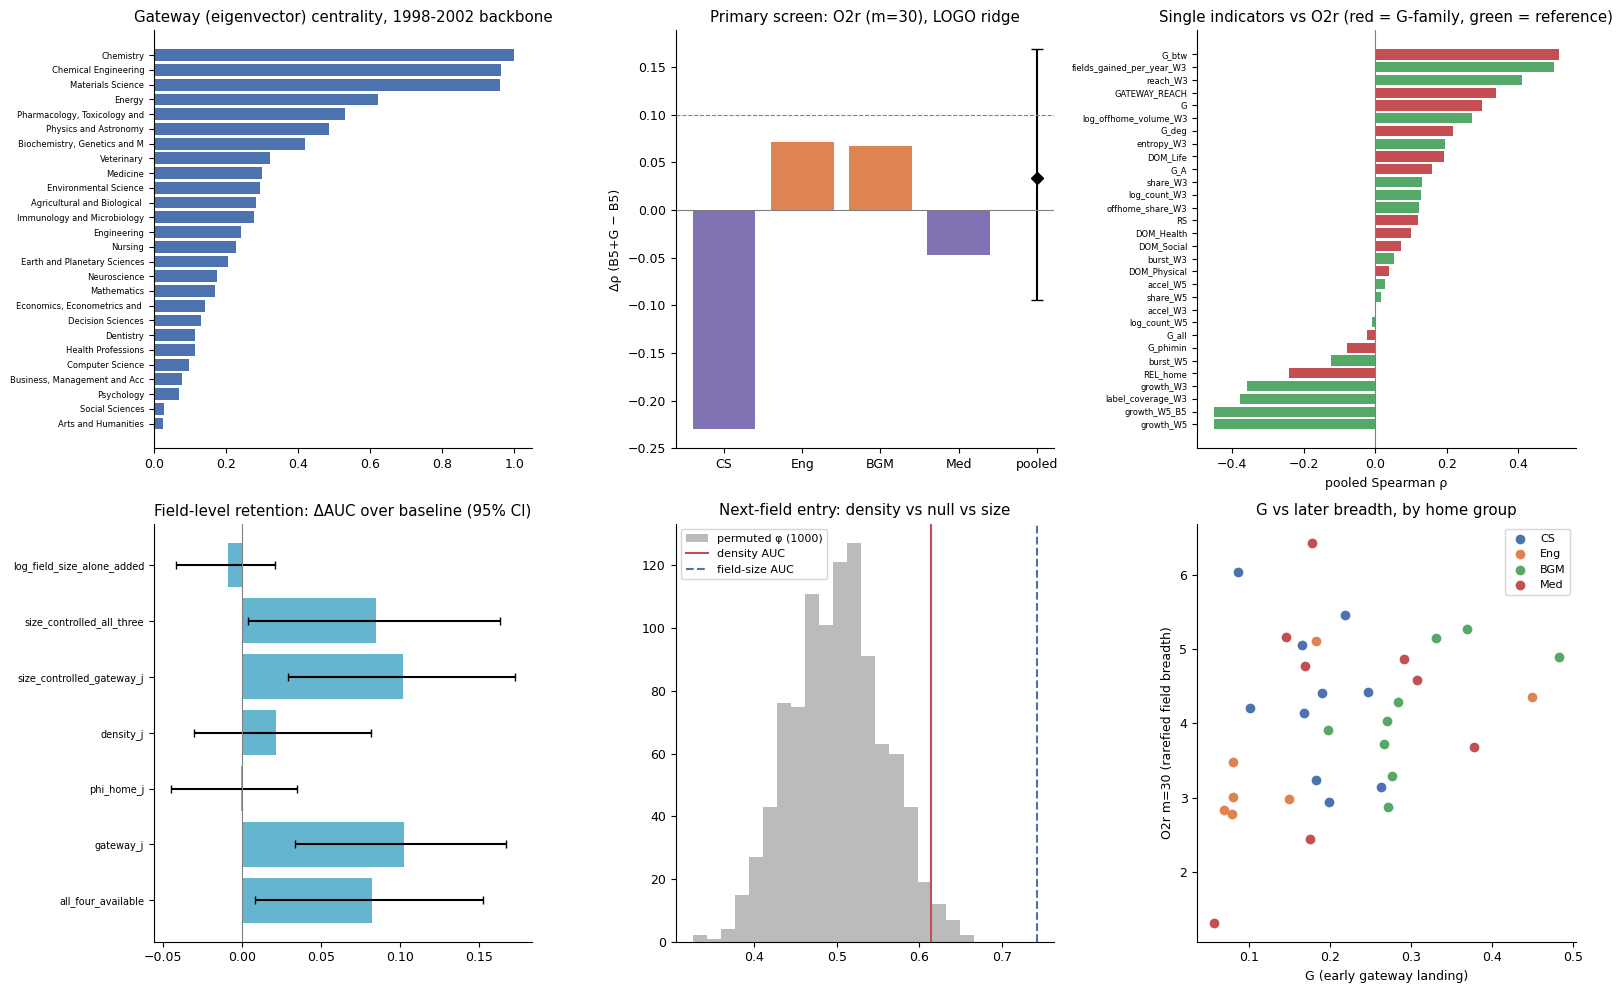

In [21]:
def _fmt_ci(ci):
    return f"[{ci[0]:+.3f}, {ci[1]:+.3f}]"

summary = pd.DataFrame([
    {"test": "Primary Δρ O2r(m=30), B5→B5+G", "demo": f"{prim['delta']:+.3f}  CI90 {_fmt_ci(prim['ci90'])}",
     "groups +": f"{prim['n_groups_positive']}/4", "published": "+0.033  CI90 [-0.095, +0.168], 2/4"},
    {"test": "Δρ O2r_resid (secondary)", "demo": f"{scr['O2r_resid']['delta']:+.3f}  CI90 {_fmt_ci(scr['O2r_resid']['ci90'])}",
     "groups +": f"{scr['O2r_resid']['n_groups_positive']}/4", "published": "+0.150  CI90 [+0.000, +0.321], 4/4"},
    {"test": "ΔAUC O1 sustained uptake", "demo": f"{scr['O1']['delta']:+.3f}  CI90 {_fmt_ci(scr['O1']['ci90'])}",
     "groups +": f"{scr['O1']['n_groups_positive']}/4", "published": "+0.072  CI90 [0.00, 0.16], 3/4"},
    {"test": "O3 transience evaluable?", "demo": str(scr["O3"]["evaluable"]),
     "groups +": f"{scr['O3']['n_positive']} positives", "published": "False (2 positives)"},
    {"test": "Split-half r_SB of G", "demo": f"{rel['G']['r_sb_median']:.3f}", "groups +": "",
     "published": "0.92"},
    {"test": "max |ρ| of G with size/growth", "demo": f"{size['max_abs']:.3f}", "groups +": "", "published": "0.13"},
    {"test": "Field retention ΔAUC (+gateway_j)", "demo": f"{fl['gateway_j']['delta_auc']:+.3f}  CI95 {_fmt_ci(fl['gateway_j']['ci95'])}",
     "groups +": "", "published": "+0.103  CI95 [0.034, 0.167]"},
    {"test": "Next-field AUC density / size", "demo": f"{nf['all']['auc_density_mean']:.3f} / {nf['all']['auc_size_mean']:.3f}",
     "groups +": f"perm p={nf['all'].get('perm_null', {}).get('p_value', float('nan')):.3f}",
     "published": "0.61 / 0.74, perm p=0.023"},
    {"test": "Verdict", "demo": screen_result["verdict"], "groups +": "", "published": "DOES NOT SURVIVE"},
])
pd.set_option("display.max_colwidth", 80)
display(summary)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
# 1 gateway centrality
ax = axes[0, 0]
gf_ = np.array(bdict["fields"]); gv_ = np.array(bdict["gateway_eig"]); o_ = np.argsort(gv_)
ax.barh([x[:28] for x in gf_[o_]], gv_[o_], color="#4C72B0")
ax.tick_params(axis="y", labelsize=6)
ax.set_title("Gateway (eigenvector) centrality, 1998-2002 backbone")
# 2 per-group delta rho
ax = axes[0, 1]
pg = prim["per_group"]
dv = [pg[g]["delta"] for g in GROUPS]
ax.bar(GROUPS, dv, color=["#DD8452" if v > 0 else "#8172B3" for v in dv])
ax.errorbar(["pooled"], [prim["delta"]], yerr=[[prim["delta"] - prim["ci90"][0]], [prim["ci90"][1] - prim["delta"]]],
            fmt="D", color="black", capsize=4)
ax.axhline(0, color="grey", lw=0.8); ax.axhline(0.10, color="grey", lw=0.8, ls="--")
ax.set_ylabel("Δρ (B5+G − B5)"); ax.set_title("Primary screen: O2r (m=30), LOGO ridge")
# 3 single indicators vs O2r
ax = axes[0, 2]
s_o2 = si[si.outcome == "O2r_m30"].sort_values("pooled_spearman")
ax.barh(s_o2["indicator"], s_o2["pooled_spearman"],
        color=["#C44E52" if f_ == "G-family" else "#55A868" for f_ in s_o2["family"]])
ax.tick_params(axis="y", labelsize=6); ax.axvline(0, color="grey", lw=0.8)
ax.set_title("Single indicators vs O2r (red = G-family, green = reference)")
ax.set_xlabel("pooled Spearman ρ")
# 4 field-level retention
ax = axes[1, 0]
fk = [k for k, v in fl.items() if isinstance(v, dict)]
fd = [fl[k]["delta_auc"] for k in fk]
ferr = np.array([[fl[k]["delta_auc"] - fl[k]["ci95"][0], fl[k]["ci95"][1] - fl[k]["delta_auc"]] for k in fk]).T
ax.barh(fk, fd, xerr=ferr, color="#64B5CD", capsize=3)
ax.axvline(0, color="grey", lw=0.8); ax.tick_params(axis="y", labelsize=7)
ax.set_title("Field-level retention: ΔAUC over baseline (95% CI)")
# 5 next-field null
ax = axes[1, 1]
pn = nf["all"].get("perm_null")
if pn:
    ax.hist(pn["values"], bins=20, color="#bbbbbb", label=f"permuted φ ({len(pn['values'])})")
ax.axvline(nf["all"]["auc_density_mean"], color="#C44E52", label="density AUC")
ax.axvline(nf["all"]["auc_size_mean"], color="#4C72B0", ls="--", label="field-size AUC")
ax.legend(fontsize=8); ax.set_title("Next-field entry: density vs null vs size")
# 6 O2r vs G scatter
ax = axes[1, 2]
cols_ = {"CS": "#4C72B0", "Eng": "#DD8452", "BGM": "#55A868", "Med": "#C44E52"}
for g in GROUPS:
    m_ = d2["group"] == g
    ax.scatter(d2.loc[m_, "G"], d2.loc[m_, "O2r_m30"], label=g, color=cols_[g])
ax.set_xlabel("G (early gateway landing)"); ax.set_ylabel("O2r m=30 (rarefied field breadth)")
ax.legend(fontsize=8); ax.set_title("G vs later breadth, by home group")
plt.tight_layout()
plt.show()